In [1]:
import os
print(os.getcwd())

e:\Tunz\PTDL_ThS\power_consumption_of_tetouan_city


In [2]:
import pandas as pd
df = pd.read_csv('Tetuan City power consumption.csv')

In [3]:
print(df.head())
print(df.shape)
print(df.info())

        DateTime  Temperature  Humidity  Wind Speed  general diffuse flows  \
0  1/1/2017 0:00        6.559      73.8       0.083                  0.051   
1  1/1/2017 0:10        6.414      74.5       0.083                  0.070   
2  1/1/2017 0:20        6.313      74.5       0.080                  0.062   
3  1/1/2017 0:30        6.121      75.0       0.083                  0.091   
4  1/1/2017 0:40        5.921      75.7       0.081                  0.048   

   diffuse flows  Zone 1 Power Consumption  Zone 2  Power Consumption  \
0          0.119               34055.69620                16128.87538   
1          0.085               29814.68354                19375.07599   
2          0.100               29128.10127                19006.68693   
3          0.096               28228.86076                18361.09422   
4          0.085               27335.69620                17872.34043   

   Zone 3  Power Consumption  
0                20240.96386  
1                20131.08434  

In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())

DateTime                     0
Temperature                  0
Humidity                     0
Wind Speed                   0
general diffuse flows        0
diffuse flows                0
Zone 1 Power Consumption     0
Zone 2  Power Consumption    0
Zone 3  Power Consumption    0
dtype: int64
0
        Temperature      Humidity    Wind Speed  general diffuse flows  \
count  52416.000000  52416.000000  52416.000000           52416.000000   
mean      18.810024     68.259518      1.959489             182.696614   
std        5.815476     15.551177      2.348862             264.400960   
min        3.247000     11.340000      0.050000               0.004000   
25%       14.410000     58.310000      0.078000               0.062000   
50%       18.780000     69.860000      0.086000               5.035500   
75%       22.890000     81.400000      4.915000             319.600000   
max       40.010000     94.800000      6.483000            1163.000000   

       diffuse flows  Zone 1 Power Cons

In [5]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
print(df['DateTime'].dtype)

datetime64[us]


In [6]:
print(df.head())

             DateTime  Temperature  Humidity  Wind Speed  \
0 2017-01-01 00:00:00        6.559      73.8       0.083   
1 2017-01-01 00:10:00        6.414      74.5       0.083   
2 2017-01-01 00:20:00        6.313      74.5       0.080   
3 2017-01-01 00:30:00        6.121      75.0       0.083   
4 2017-01-01 00:40:00        5.921      75.7       0.081   

   general diffuse flows  diffuse flows  Zone 1 Power Consumption  \
0                  0.051          0.119               34055.69620   
1                  0.070          0.085               29814.68354   
2                  0.062          0.100               29128.10127   
3                  0.091          0.096               28228.86076   
4                  0.048          0.085               27335.69620   

   Zone 2  Power Consumption  Zone 3  Power Consumption  
0                16128.87538                20240.96386  
1                19375.07599                20131.08434  
2                19006.68693                19668.

In [7]:
df['DateTime'].diff().value_counts()

DateTime
0 days 00:10:00    52415
Name: count, dtype: int64

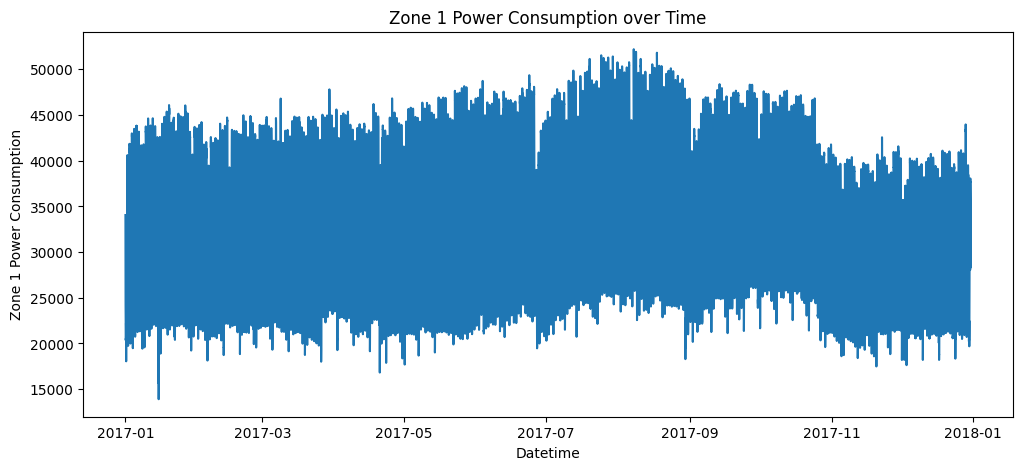

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['DateTime'], df['Zone 1 Power Consumption'])
plt.xlabel('Datetime')
plt.ylabel('Zone 1 Power Consumption')
plt.title('Zone 1 Power Consumption over Time')
plt.show()

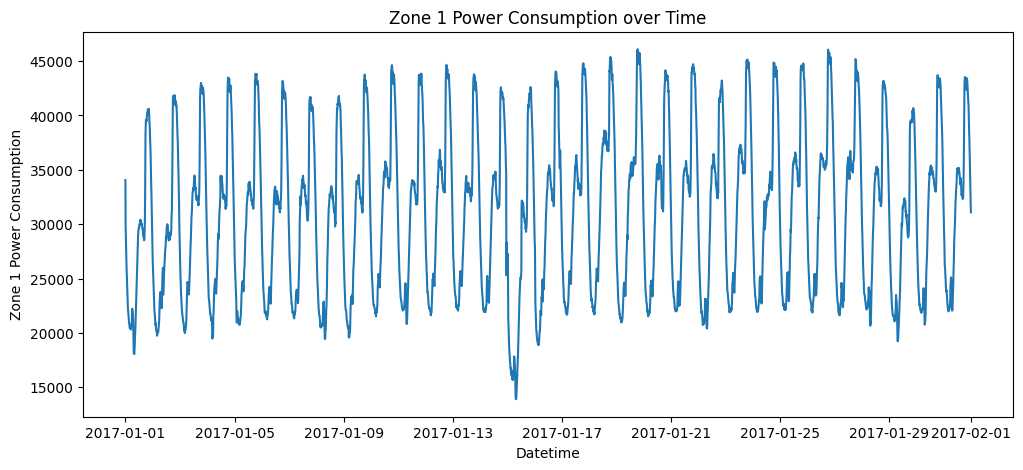

In [9]:
df_month = df[
    (df['DateTime'] >= '2017-01-01') &
    (df['DateTime'] < '2017-02-01')
]
plt.figure(figsize=(12,5))
plt.plot(df_month['DateTime'], df_month['Zone 1 Power Consumption'])
plt.xlabel('Datetime')
plt.ylabel('Zone 1 Power Consumption')
plt.title('Zone 1 Power Consumption over Time')
plt.show()

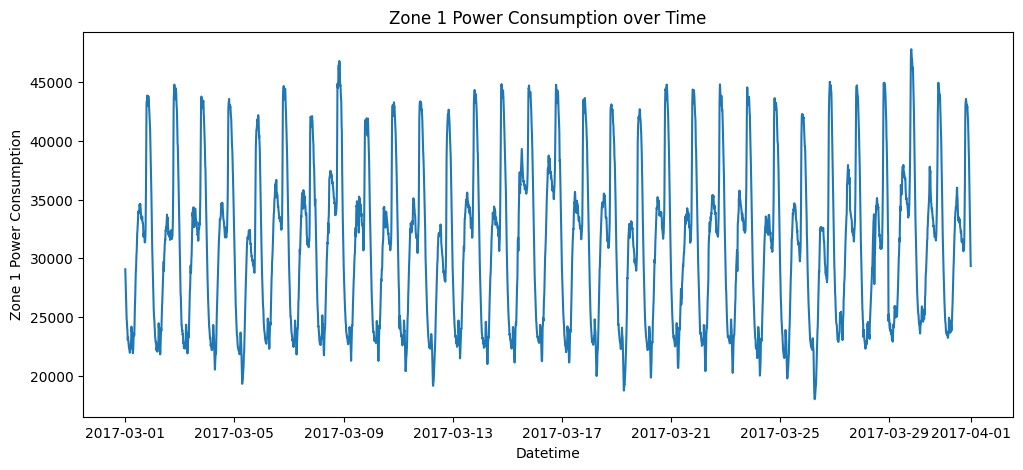

In [10]:
df_month = df[
    (df['DateTime'] >= '2017-03-01') &
    (df['DateTime'] < '2017-04-01')
]
plt.figure(figsize=(12,5))
plt.plot(df_month['DateTime'], df_month['Zone 1 Power Consumption'])
plt.xlabel('Datetime')
plt.ylabel('Zone 1 Power Consumption')
plt.title('Zone 1 Power Consumption over Time')
plt.show()

In [11]:
df["year"] = df["DateTime"].dt.year
df["month"] = df["DateTime"].dt.month
df["day"] = df["DateTime"].dt.day
df["hour"] = df["DateTime"].dt.hour
df["minute"] = df["DateTime"].dt.minute
df["day_of_week"] = df["DateTime"].dt.dayofweek

In [12]:
df.describe()
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,year,month,day,hour,minute,day_of_week
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,2017,1,1,0,0,6
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,2017,1,1,0,10,6
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,2017,1,1,0,20,6
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,2017,1,1,0,30,6
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,2017,1,1,0,40,6


In [13]:
df['zone_1_lag_1'] = df['Zone 1 Power Consumption'].shift(1)
df['zone_1_lag_6'] = df['Zone 1 Power Consumption'].shift(6)
df['zone_1_lag_144'] = df['Zone 1 Power Consumption'].shift(144)
df['zone_1_lag_1008'] = df['Zone 1 Power Consumption'].shift(1008)

In [14]:
df.describe()
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,year,month,day,hour,minute,day_of_week,zone_1_lag_1,zone_1_lag_6,zone_1_lag_144,zone_1_lag_1008
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,2017,1,1,0,0,6,NaN,NaN,NaN,NaN
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,2017,1,1,0,10,6,34055.69620,NaN,NaN,NaN
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,2017,1,1,0,20,6,29814.68354,NaN,NaN,NaN
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,2017,1,1,0,30,6,29128.10127,NaN,NaN,NaN
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,2017,1,1,0,40,6,28228.86076,NaN,NaN,NaN


In [15]:
df['power_rolling_mean_6'] = (df['Zone 1 Power Consumption'].shift(1).rolling(6).mean())
df['power_rolling_mean_144'] = (df['Zone 1 Power Consumption'].shift(1).rolling(144).mean())
df['power_rolling_mean_1008'] = (df['Zone 1 Power Consumption'].shift(1).rolling(1008).mean())

df['power_rolling_std_6'] = (df['Zone 1 Power Consumption'].shift(1).rolling(6).std())
df['power_rolling_std_144'] = (df['Zone 1 Power Consumption'].shift(1).rolling(144).std())
df['power_rolling_std_1008'] = (df['Zone 1 Power Consumption'].shift(1).rolling(1008).std())


In [16]:
df.describe()
df.head(10)

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,year,...,zone_1_lag_1,zone_1_lag_6,zone_1_lag_144,zone_1_lag_1008,power_rolling_mean_6,power_rolling_mean_144,power_rolling_mean_1008,power_rolling_std_6,power_rolling_std_144,power_rolling_std_1008
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,2017,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,2017,...,34055.69620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,2017,...,29814.68354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,2017,...,29128.10127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,2017,...,28228.86076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017-01-01 00:50:00,5.853,76.9,0.081,0.059,0.108,26624.81013,17416.41337,18130.12048,2017,...,27335.69620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2017-01-01 01:00:00,5.641,77.7,0.080,0.048,0.096,25998.98734,16993.31307,17945.06024,2017,...,26624.81013,34055.69620,NaN,NaN,29197.974683,NaN,NaN,2646.171166,NaN,NaN
7,2017-01-01 01:10:00,5.496,78.2,0.085,0.055,0.093,25446.07595,16661.39818,17459.27711,2017,...,25998.98734,29814.68354,NaN,NaN,27855.189873,NaN,NaN,1471.648370,NaN,NaN
8,2017-01-01 01:20:00,5.678,78.1,0.081,0.066,0.141,24777.72152,16227.35562,17025.54217,2017,...,25446.07595,29128.10127,NaN,NaN,27127.088608,NaN,NaN,1386.518689,NaN,NaN
9,2017-01-01 01:30:00,5.491,77.3,0.082,0.062,0.111,24279.49367,15939.20973,16794.21687,2017,...,24777.72152,28228.86076,NaN,NaN,26402.025317,NaN,NaN,1262.801944,NaN,NaN


In [17]:
print(df.columns)
print(type(df.columns))


Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption', 'year',
       'month', 'day', 'hour', 'minute', 'day_of_week', 'zone_1_lag_1',
       'zone_1_lag_6', 'zone_1_lag_144', 'zone_1_lag_1008',
       'power_rolling_mean_6', 'power_rolling_mean_144',
       'power_rolling_mean_1008', 'power_rolling_std_6',
       'power_rolling_std_144', 'power_rolling_std_1008'],
      dtype='str')
<class 'pandas.Index'>


In [18]:
features = df.columns
features = features.drop(['DateTime', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption'])
X = df[features]
print(features)
y = df['Zone 1 Power Consumption']

Index(['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows',
       'diffuse flows', 'year', 'month', 'day', 'hour', 'minute',
       'day_of_week', 'zone_1_lag_1', 'zone_1_lag_6', 'zone_1_lag_144',
       'zone_1_lag_1008', 'power_rolling_mean_6', 'power_rolling_mean_144',
       'power_rolling_mean_1008', 'power_rolling_std_6',
       'power_rolling_std_144', 'power_rolling_std_1008'],
      dtype='str')


In [33]:
n = len(df)
train_idx = int(n * 0.7)
valid_idx = int(n * 0.85)
X_train = X.iloc[:train_idx]
y_train = y.iloc[:train_idx]
X_valid = X.iloc[train_idx : valid_idx]
y_valid = y.iloc[train_idx : valid_idx]
X_test = X.iloc[valid_idx:]
y_test = y.iloc[valid_idx:]

In [34]:
import sklearn

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 6,
    objective = 'reg:squarederror'
)


In [35]:
model.fit(
    X_train, 
    y_train,
    eval_set = [(X_valid, y_valid)],
    verbose = False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [36]:
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(r2)

570.7748601226075
743.4513471200551
0.9849388515935947


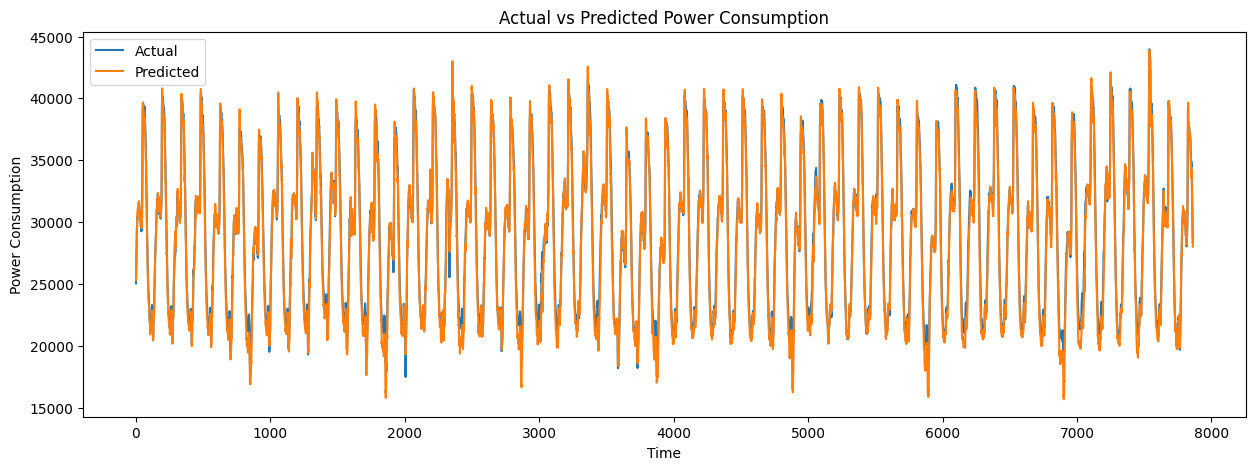

In [38]:
plt.figure(figsize=(15, 5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.xlabel("Time")
plt.ylabel("Power Consumption")
plt.title("Actual vs Predicted Power Consumption")
plt.legend()

plt.show()

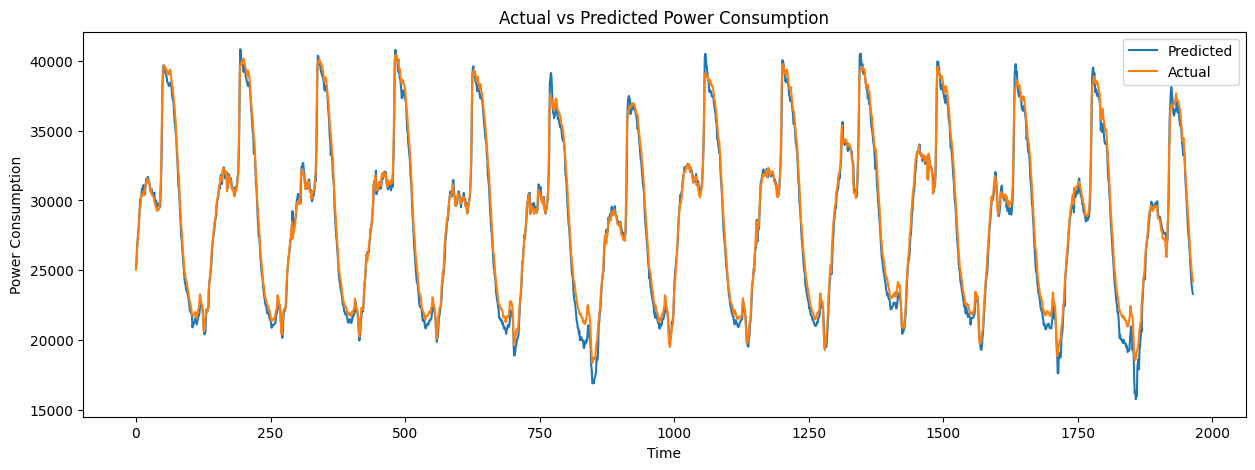

In [40]:
y_test_cut = y_test.iloc[:int(0.25 * len(y_test))]
y_pred_cut = y_pred[:int(0.25 * len(y_pred))]

plt.figure(figsize=(15, 5))

plt.plot(y_pred_cut, label="Predicted")
plt.plot(y_test_cut.values, label="Actual")
plt.xlabel("Time")
plt.ylabel("Power Consumption")
plt.title("Actual vs Predicted Power Consumption")
plt.legend()

plt.show()
# plt.figure(figsize=(15, 5))


# plt.xlabel("Time")
# plt.ylabel("Power Consumption")
# plt.title("Actual vs Predicted Power Consumption")
# plt.legend()

# plt.show()

<Figure size 1000x800 with 0 Axes>

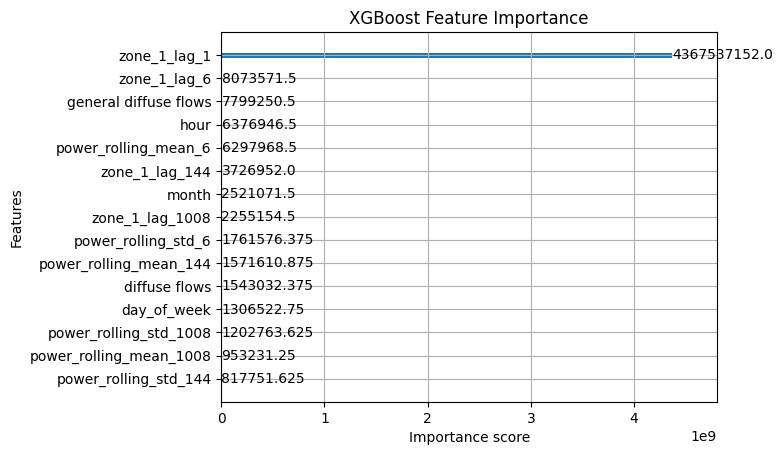

In [41]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plot_importance(
    model,
    importance_type='gain',
    max_num_features=15
)

plt.title("XGBoost Feature Importance")
plt.show()

In [42]:
importance = model.get_booster().get_score(
    importance_type='gain'
)

importance_df = pd.DataFrame(
    importance.items(),
    columns=['Feature', 'Gain']
)

importance_df['Importance (%)'] = (
    importance_df['Gain'] /
    importance_df['Gain'].sum()
) * 100

importance_df = importance_df.sort_values(
    'Importance (%)',
    ascending=False
)

print(importance_df)

                    Feature          Gain  Importance (%)
10             zone_1_lag_1  4.367537e+09       98.870066
11             zone_1_lag_6  8.073572e+06        0.182765
3     general diffuse flows  7.799250e+06        0.176555
7                      hour  6.376946e+06        0.144358
14     power_rolling_mean_6  6.297968e+06        0.142570
12           zone_1_lag_144  3.726952e+06        0.084369
5                     month  2.521072e+06        0.057071
13          zone_1_lag_1008  2.255154e+06        0.051051
17      power_rolling_std_6  1.761576e+06        0.039878
15   power_rolling_mean_144  1.571611e+06        0.035577
4             diffuse flows  1.543032e+06        0.034930
9               day_of_week  1.306523e+06        0.029576
19   power_rolling_std_1008  1.202764e+06        0.027228
16  power_rolling_mean_1008  9.532312e+05        0.021579
18    power_rolling_std_144  8.177516e+05        0.018512
8                    minute  8.081598e+05        0.018295
1             